In [2]:
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from pathlib import Path
from great_tables import GT

In [3]:
df_metrics = pl.read_csv("results/all_sites_RGB_bw3_metrics_combined.csv")
df_metrics

dataset,acc,f1,precision,recall,miou,sensitivity,specificity,roc_auc
str,f64,f64,f64,f64,f64,f64,f64,f64
"""CW JR East Train""",0.823188,0.722172,0.739104,0.705999,0.6677952,0.705999,0.879739,0.792869
"""CW JR East Validation""",0.829113,0.76039,0.758423,0.762368,0.6894749,0.762368,0.865956,0.814162
"""CW JR East Test""",0.819233,0.629791,0.731348,0.553,0.62301,0.553,0.921766,0.737383
"""Cw JR Sandcut Train""",0.760315,0.496086,0.725635,0.376867,0.5290585,0.376867,0.935062,0.655964
"""Cw JR Sandcut Validation""",0.757388,0.486734,0.677631,0.379753,0.523748,0.379753,0.921493,0.650623
…,…,…,…,…,…,…,…,…
"""Fdc_JR_W45 Validation""",0.890835,0.712537,0.973814,0.561804,0.7135989,0.561804,0.995208,0.778506
"""Fdc_JR_W45 Test""",0.868222,0.568272,0.96932,0.401964,0.626311,0.401964,0.9965,0.699232
"""Fdc_PR_Canoe Train""",0.716915,0.045401,0.741523,0.023417,0.369112,0.023417,0.996707,0.510062


In [4]:
df_metrics = df_metrics.select([
    pl.col("dataset").str.extract(r"(.*?)\s+(Train|Validation|Test)$", 1).alias("site"),
    pl.col("dataset").str.extract(r"(.*?)\s+(Train|Validation|Test)$", 2).alias("phase").str.to_lowercase(),
    pl.exclude("dataset")
])
df_metrics

site,phase,acc,f1,precision,recall,miou,sensitivity,specificity,roc_auc
str,str,f64,f64,f64,f64,f64,f64,f64,f64
"""CW JR East""","""train""",0.823188,0.722172,0.739104,0.705999,0.6677952,0.705999,0.879739,0.792869
"""CW JR East""","""validation""",0.829113,0.76039,0.758423,0.762368,0.6894749,0.762368,0.865956,0.814162
"""CW JR East""","""test""",0.819233,0.629791,0.731348,0.553,0.62301,0.553,0.921766,0.737383
"""Cw JR Sandcut""","""train""",0.760315,0.496086,0.725635,0.376867,0.5290585,0.376867,0.935062,0.655964
"""Cw JR Sandcut""","""validation""",0.757388,0.486734,0.677631,0.379753,0.523748,0.379753,0.921493,0.650623
…,…,…,…,…,…,…,…,…,…
"""Fdc_JR_W45""","""validation""",0.890835,0.712537,0.973814,0.561804,0.7135989,0.561804,0.995208,0.778506
"""Fdc_JR_W45""","""test""",0.868222,0.568272,0.96932,0.401964,0.626311,0.401964,0.9965,0.699232
"""Fdc_PR_Canoe""","""train""",0.716915,0.045401,0.741523,0.023417,0.369112,0.023417,0.996707,0.510062


In [7]:
df_metrics.write_csv("output/all_sites_metrics.csv")

In [ ]:
df_means = df_metrics.select(["phase", "miou", "f1", "precision", "recall", "specificity", "acc"]).group_by("phase").mean()
df_means

phase,miou,f1,precision,recall,specificity,acc
str,f64,f64,f64,f64,f64,f64
"""train""",0.565388,0.560576,0.807879,0.482725,0.92115,0.773604
"""validation""",0.590219,0.607146,0.832503,0.545964,0.913037,0.775172
"""test""",0.575582,0.574245,0.804006,0.499775,0.915597,0.783996


In [ ]:
gt_table = (
    GT(df_means)
    .tab_header(
        title="Comparaison des performances moyennes par phase",
        subtitle="Métriques de segmentation des couronnes d'arbres"
    )
    .fmt_number(
        columns=["acc", "f1", "precision", "recall", "miou", "specificity"],
        decimals=3
    )
    .cols_label(
        phase="Phase",
        acc="Accuracy",
        f1="F1-Score",
        precision="Precision",
        recall="Recall",
        miou="mIoU",
        specificity="Specificity"
    )
)

gt_table

latex_code = gt_table.as_latex()
print(latex_code)

\begin{table}[!t]
\caption*{
{\large Comparaison des performances moyennes par phase} \\
{\small Métriques de segmentation des couronnes d'arbres}
} 

\fontsize{12.0pt}{14.4pt}\selectfont

\begin{tabular*}{\linewidth}{@{\extracolsep{\fill}}lrrrrrr}
\toprule
Phase & mIoU & F1-Score & Precision & Recall & Specificity & Accuracy \\ 
\midrule\addlinespace[2.5pt]
train & 0.565 & 0.561 & 0.808 & 0.483 & 0.921 & 0.774 \\
validation & 0.590 & 0.607 & 0.833 & 0.546 & 0.913 & 0.775 \\
test & 0.576 & 0.574 & 0.804 & 0.500 & 0.916 & 0.784 \\
\bottomrule
\end{tabular*}

\end{table}



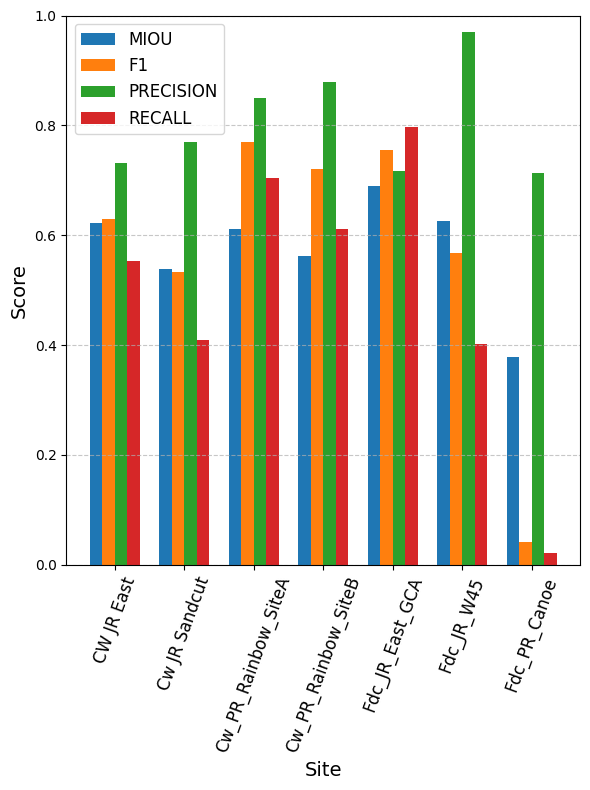

In [ ]:
df_analysis = df_metrics.with_columns([
    (pl.col("f1") / pl.col("miou")).alias("f1_miou_ratio"),
    ((2 * pl.col("precision") * pl.col("recall")) / 
     (pl.col("precision") + pl.col("recall") + 1e-7)).alias("harmonic_balance")
])

test_data = df_analysis.filter(pl.col("phase") == "test")
site_names = test_data["site"].to_list()
metrics_to_plot = ["miou", "f1", "precision", "recall"]
metrics_data = {metric: test_data[metric].to_list() for metric in metrics_to_plot}

fig, ax = plt.subplots(figsize=(6, 8))
width = 0.18

x = np.arange(len(site_names))
bars = []
for i, (metric, values) in enumerate(metrics_data.items()):
    position = x + (i - 1.5) * width
    bar = ax.bar(position, values, width, label=metric.upper())
    bars.append(bar)

ax.set_xlabel("Site", fontsize=14)
ax.set_ylabel("Score", fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(site_names, rotation=70, ha="center", fontsize=12)  # Rotation à 90° pour gagner de l'espace
ax.set_ylim(0, 1.0)
ax.legend(fontsize=12)
ax.grid(axis="y", linestyle="--", alpha=0.7)


plt.tight_layout()
plt.savefig("output/metrics_by_site_test.png", dpi=300, bbox_inches="tight")
plt.show()


In [ ]:
df_analysis

site,phase,acc,f1,precision,recall,miou,sensitivity,specificity,roc_auc,f1_miou_ratio,harmonic_balance
str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""CW JR East""","""train""",0.823188,0.722172,0.739104,0.705999,0.6677952,0.705999,0.879739,0.792869,1.081428,0.722172
"""CW JR East""","""validation""",0.829113,0.76039,0.758423,0.762368,0.6894749,0.762368,0.865956,0.814162,1.102854,0.76039
"""CW JR East""","""test""",0.819233,0.629791,0.731348,0.553,0.62301,0.553,0.921766,0.737383,1.010885,0.629791
"""Cw JR Sandcut""","""train""",0.760315,0.496086,0.725635,0.376867,0.5290585,0.376867,0.935062,0.655964,0.937676,0.496086
"""Cw JR Sandcut""","""validation""",0.757388,0.486734,0.677631,0.379753,0.523748,0.379753,0.921493,0.650623,0.929329,0.486734
…,…,…,…,…,…,…,…,…,…,…,…
"""Fdc_JR_W45""","""validation""",0.890835,0.712537,0.973814,0.561804,0.7135989,0.561804,0.995208,0.778506,0.998512,0.712537
"""Fdc_JR_W45""","""test""",0.868222,0.568272,0.96932,0.401964,0.626311,0.401964,0.9965,0.699232,0.907333,0.568272
"""Fdc_PR_Canoe""","""train""",0.716915,0.045401,0.741523,0.023417,0.369112,0.023417,0.996707,0.510062,0.123001,0.045401


In [ ]:
df_bw = pl.read_csv("results/all_models_means.csv")
df_bw = df_bw.filter(pl.col("phase") == "validation")
df_bw = df_bw.select(["model", "boundary_weight", "miou", "f1", "precision", "recall"])
df_bw


model,boundary_weight,miou,f1,precision,recall
str,f64,f64,f64,f64,f64
"""RGB""",2.0,0.522473,0.43488,0.686301,0.386687
"""RGB""",3.0,0.590219,0.607146,0.832503,0.545964
"""RGB""",4.0,0.552458,0.481127,0.812657,0.437126
"""RGB""",5.0,0.561363,0.505885,0.856171,0.444723
"""RGBNIR""",1.5,0.565402,0.544041,0.841839,0.469083
"""RGBNIR""",3.0,0.539988,0.498557,0.860967,0.41205


In [ ]:
gt_bw_table = (
    GT(df_bw)
    .tab_header(
        title="Impact du poids des frontières sur les performances du modèle",
        subtitle="Comparaison des métriques sur l'ensemble de validation"
    )
    .fmt_number(
        columns=["miou", "f1", "precision", "recall"],
        decimals=3
    )
    .cols_label(
        model="Modèle",
        boundary_weight="Poids des frontières",
        miou="mIoU",
        f1="F1-Score",
        precision="Precision",
        recall="Recall"
    )

)

gt_bw_table

latex_bw_code = gt_bw_table.as_latex()
print("\nCode LaTeX pour la table des boundary weights:")
print(latex_bw_code)

Path("output").mkdir(exist_ok=True)

with open("output/boundary_weights_table.tex", "w") as f:
    f.write(latex_bw_code)


Code LaTeX pour la table des boundary weights:
\begin{table}[!t]
\caption*{
{\large Impact du poids des frontières sur les performances du modèle} \\
{\small Comparaison des métriques sur l'ensemble de validation}
} 

\fontsize{12.0pt}{14.4pt}\selectfont

\begin{tabular*}{\linewidth}{@{\extracolsep{\fill}}lrrrrr}
\toprule
Modèle & Poids des frontières & mIoU & F1-Score & Precision & Recall \\ 
\midrule\addlinespace[2.5pt]
RGB & 2.0 & 0.522 & 0.435 & 0.686 & 0.387 \\
RGB & 3.0 & 0.590 & 0.607 & 0.833 & 0.546 \\
RGB & 4.0 & 0.552 & 0.481 & 0.813 & 0.437 \\
RGB & 5.0 & 0.561 & 0.506 & 0.856 & 0.445 \\
RGBNIR & 1.5 & 0.565 & 0.544 & 0.842 & 0.469 \\
RGBNIR & 3.0 & 0.540 & 0.499 & 0.861 & 0.412 \\
\bottomrule
\end{tabular*}

\end{table}

